<a href="https://colab.research.google.com/github/StephanyMejia25/caso-practico-2524022017/blob/main/archivos/casoPractico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# URL del dataset modificado (nuestro punto de partida)
url = "https://raw.githubusercontent.com/StephanyMejia25/caso-practico-2524022017/refs/heads/main/archivos/Prestige_modificado.csv"

# 1. Carga con delimitador específico
df = pd.read_csv(url, sep=';')

# 2. LIMPIEZA DE DUPLICADOS
# En la producción de software, los datos duplicados generan costos y errores de cálculo.
antes = df.shape[0]
df = df.drop_duplicates()
print(f"✅ Registros duplicados eliminados: {antes - df.shape[0]}")

# 3. TRATAMIENTO DE NULOS
# Propósito: Asegurar que el modelo de ML no falle por valores vacíos.
# Eliminamos filas donde 'type_num' sea nulo si es nuestra variable de segmentación clave.
df = df.dropna(subset=['type_num'])

# 4. TRASFORMACIÓN DE VARIABLES (Mapeo de 'type')
# Propósito: Hacer que los datos sean interpretables para Gerencia.
mapeo_tipos = {
    1: 'prof', # Profesional/Técnico
    2: 'bc',   # Blue Collar (Operativo)
    3: 'wc',   # White Collar (Administrativo)
    0: 'n/a'   # No aplicable
}
df['type'] = df['type_num'].map(mapeo_tipos)

# 5. INSPECCIÓN FINAL
print("\n--- DATASET TRANSFORMADO (ESTILO INNOVASOFT) ---")
print(df.head())
print("\n--- ESTADÍSTICAS CLAVE ---")
display(df.describe())

✅ Registros duplicados eliminados: 0

--- DATASET TRANSFORMADO (ESTILO INNOVASOFT) ---
            occupation  education  income  women  prestige  census  type_num  \
0   gov.administrators      13.11   12351  11.16      68.8    1113         1   
1     general.managers      12.26   25879   4.02      69.1    1130         1   
2          accountants      12.77    9271  15.70      63.4    1171         1   
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1   
4             chemists      14.62    8403  11.68      73.5    2111         1   

   type  
0  prof  
1  prof  
2  prof  
3  prof  
4  prof  

--- ESTADÍSTICAS CLAVE ---


,education,income,women,prestige,census,type_num
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,10.738039,6797.901961,28.979020,46.833333,5401.774510,1.843137
std,2.728444,4245.922227,31.724931,17.204486,2644.993215,0.817447
min,6.380000,611.000000,0.000000,14.800000,1113.000000,0.000000
25%,8.445000,4106.000000,3.592500,35.225000,3120.500000,1.000000
50%,10.540000,5930.500000,13.600000,43.600000,5135.000000,2.000000
75%,12.647500,8187.250000,52.202500,59.275000,8312.500000,2.000000
max,15.970000,25879.000000,97.510000,87.200000,9517.000000,3.000000


In [ ]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())


(102, 8)
            occupation  education  income  women  prestige  census  type_num  \
0   gov.administrators      13.11   12351  11.16      68.8    1113         1   
1     general.managers      12.26   25879   4.02      69.1    1130         1   
2          accountants      12.77    9271  15.70      63.4    1171         1   
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1   
4             chemists      14.62    8403  11.68      73.5    2111         1   

   type  
0  prof  
1  prof  
2  prof  
3  prof  
4  prof  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    1

In [ ]:
# 1. Normalización de nombres de columnas
# Propósito: Convertir los nombres
df.columns = [col.capitalize() for col in df.columns]
print("Columnas actuales:", df.columns.tolist())

# 2. Selección de variables numéricas
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

# 3. Cálculo de la matriz de correlación
matriz_correlacion = variables_numericas.corr()

# 4. Ordenar correlaciones
print("\n--- RELACIÓN DE VARIABLES CON EL PRESTIGIO (ORDEN DESCENDENTE) ---")
print(matriz_correlacion['Prestige'].sort_values(ascending=False).round(3))

Columnas actuales: ['Occupation', 'Education', 'Income', 'Women', 'Prestige', 'Census', 'Type_num', 'Type']

--- RELACIÓN DE VARIABLES CON EL PRESTIGIO (ORDEN DESCENDENTE) ---
Prestige     1.000
Education    0.850
Income       0.715
Women       -0.118
Type_num    -0.465
Census      -0.635
Name: Prestige, dtype: float64


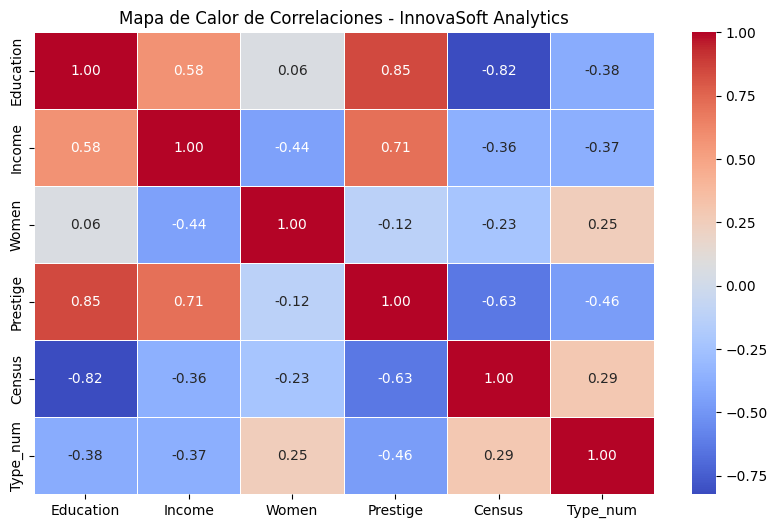


--- RELACIÓN DE VARIABLES CON EL PRESTIGIO (ORDEN DESCENDENTE) ---
Prestige     1.000
Education    0.850
Income       0.715
Women       -0.118
Type_num    -0.465
Census      -0.635
Name: Prestige, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selección de variables numéricas
# Propósito: Aislar los datos cuantitativos para cálculos matemáticos.
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

# 2. Cálculo de la matriz de correlación (Método de Pearson)
matriz_correlacion = variables_numericas.corr()

# 3. Visualización Industrial (Heatmap)
# Propósito: Facilitar la identificación de relaciones fuertes vs. débiles.
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones - InnovaSoft Analytics')
plt.show()

# 4. Ordenar correlaciones respecto a 'Prestige'
# Propósito: Jerarquizar la importancia de los factores sobre la valoración social.
print("\n--- RELACIÓN DE VARIABLES CON EL PRESTIGIO (ORDEN DESCENDENTE) ---")
print(matriz_correlacion['Prestige'].sort_values(ascending=False).round(3))

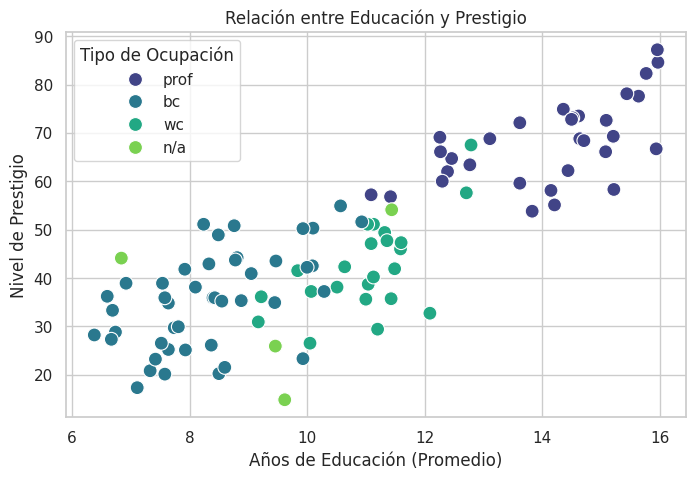

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración estética para InnovaSoft
sns.set_theme(style="whitegrid")

# 1. Gráfica de Dispersión: Educación vs. Prestigio
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Education', y='Prestige', hue='Type', palette='viridis', s=100)
plt.title('Relación entre Educación y Prestigio')
plt.xlabel('Años de Educación (Promedio)')
plt.ylabel('Nivel de Prestigio')
plt.legend(title='Tipo de Ocupación')
plt.show()

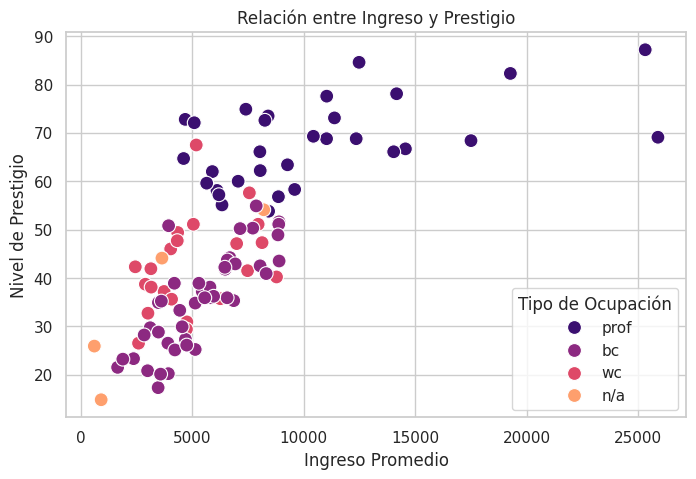

In [ ]:
# 2. Gráfica de Dispersión: Ingreso vs. Prestigio
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Income', y='Prestige', hue='Type', palette='magma', s=100)
plt.title('Relación entre Ingreso y Prestigio')
plt.xlabel('Ingreso Promedio')
plt.ylabel('Nivel de Prestigio')
plt.legend(title='Tipo de Ocupación')
plt.show()



/tmp/ipykernel_7914/3142897992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Prestige', palette='Set2')


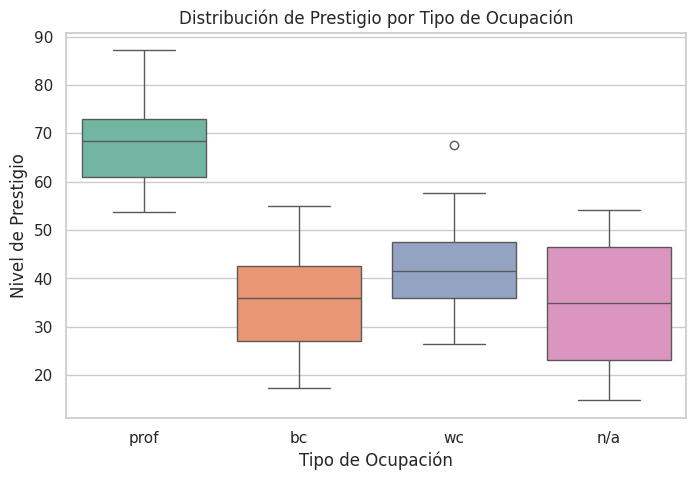

In [ ]:
# 3. Gráfica de Comparación: Prestigio por Tipo de Ocupación (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Type', y='Prestige', palette='Set2')
plt.title('Distribución de Prestigio por Tipo de Ocupación')
plt.xlabel('Tipo de Ocupación')
plt.ylabel('Nivel de Prestigio')
plt.show()

/tmp/ipykernel_7914/1054298189.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y='Prestige', palette='viridis', inner=None, alpha=0.3)
/tmp/ipykernel_7914/1054298189.py:15: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df, x='Type', y='Prestige', hue='Type', palette='viridis',


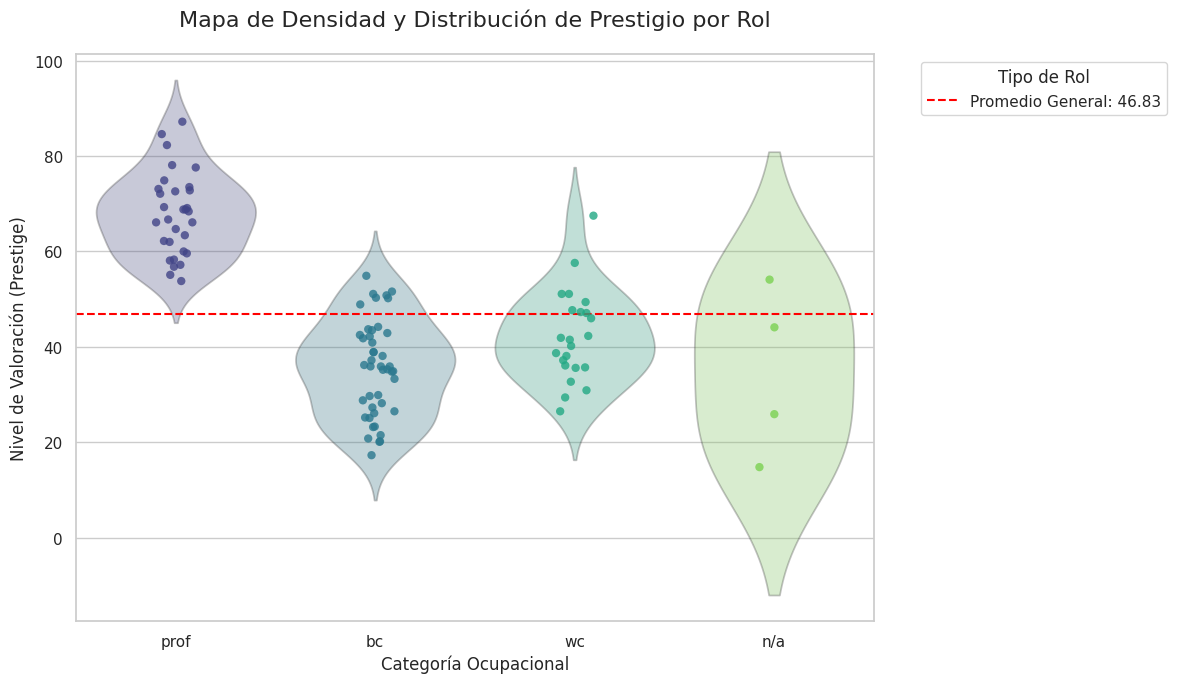

In [ ]:
#ESTE ES APORTE MIO PARA UNA MEJOR COMPRESION:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos un estilo visual moderno
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Creamos un gráfico de violín para ver la densidad y distribución
# El 'inner=None' quita la caja interna para que no se vea saturado
sns.violinplot(data=df, x='Type', y='Prestige', palette='viridis', inner=None, alpha=0.3)

# Superponemos un 'stripplot' para ver cada ocupación como un punto individual
# Esto permite ver la dispersión real de los datos
sns.stripplot(data=df, x='Type', y='Prestige', hue='Type', palette='viridis',
              size=6, jitter=True, edgecolor='gray', alpha=0.8)

# Añadimos una línea horizontal con el promedio general de prestigio de la empresa
plt.axhline(df['Prestige'].mean(), color='red', linestyle='--', label=f'Promedio General: {df["Prestige"].mean():.2f}')

# Personalización de etiquetas para que sea "Gerencial"
plt.title('Mapa de Densidad y Distribución de Prestigio por Rol', fontsize=16, pad=20)
plt.xlabel('Categoría Ocupacional', fontsize=12)
plt.ylabel('Nivel de Valoración (Prestige)', fontsize=12)
plt.legend(title='Tipo de Rol', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Selección de variables para el modelo
# Incluimos variables que definen el perfil socioeconómico y el rol
columnas_cluster = ['Education', 'Income', 'Women', 'Prestige', 'Type_num']
X = df[columnas_cluster].copy()

# 2. Escalado de Datos (Paso Industrial Crítico)
# Propósito: Evitar que 'Income' (miles) domine sobre 'Education' (unidades)
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

# 3. Construcción de Modelos
# Modelo A: 4 Clústeres
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

# Modelo B: 5 Clústeres
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

# 4. Visualización de Centroides (Promedios por grupo)
print("--- ANÁLISIS DE CENTROIDES: MODELO DE 4 GRUPOS ---")
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))

print("\n--- ANÁLISIS DE CENTROIDES: MODELO DE 5 GRUPOS ---")
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))

--- ANÁLISIS DE CENTROIDES: MODELO DE 4 GRUPOS ---
           Education    Income  Women  Prestige  Type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00

--- ANÁLISIS DE CENTROIDES: MODELO DE 5 GRUPOS ---
           Education    Income  Women  Prestige  Type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
